# Phase 19 — Cross-Dataset Sequential LoRA Fine-tuning

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Author:** Milani, S. — University of Padova

---

## Design

```
PHASE 1 — Backbone pre-training (Dataset 1, standard supervised training)
──────────────────────────────────────────────────────────────────────────
  All 118 subjects, all windows, one training run (no continual learning).
  Architecture: Conv1d × 4  →  AdaptiveAvgPool1d  →  Linear(flat, 128)
  Output: frozen backbone weights  W_cnn  +  W_emb

PHASE 2 — Cross-dataset sequential LoRA fine-tuning
──────────────────────────────────────────────────────────────────────────
  No CDML.  No within-dataset task splits.
  Continual learning is at the DATASET level.
  Each dataset trained in a SINGLE run (whole dataset at once).
  LoRA adapter (A, B) + fresh classifier trained jointly per dataset.

  Baseline:  UCI HAR ──(fresh init)─────────────────┐
             WISDM   ──(fresh init)─────────────────┘  independent

  Order A:   D1  →  UCI HAR (fresh)   →  save LoRA_UCI
                 →  WISDM  (warm-start from LoRA_UCI)

  Order B:   D1  →  WISDM  (fresh)   →  save LoRA_WISDM
                 →  UCI HAR (warm-start from LoRA_WISDM)
```

### Key differences vs Phase 18

| | Phase 18 | Phase 19 |
|---|---|---|
| CL granularity | Within-dataset (4 tasks) | Between datasets |
| Within-dataset training | 4 tasks, task-level CL | Whole dataset at once |
| CDML | Yes (per-task sequences) | **No** |
| LoRA per dataset | 4 adapters (one per task) | 1 adapter (whole dataset) |
| Warm-start | No | Yes (cross-dataset) |

### Experiments at a glance

| Experiment | UCI HAR LoRA init | WISDM LoRA init |
|---|---|---|
| Baseline | fresh | fresh |
| Order A (UCI→WSD) | fresh | warm-start from UCI |
| Order B (WSD→UCI) | warm-start from WSD | fresh |


## 0. Imports

In [1]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split
)
from copy import deepcopy
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

DEVICE = torch.device('cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cpu
PyTorch: 2.8.0


## 1. Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
D1_TRAIN_DIR = '../Data/Dataset_1/train'
D1_TEST_DIR  = '../Data/Dataset_1/test'
UCI_DATA_DIR = '../Data/UCI HAR Dataset'
WSD_DATA_DIR = '../Data/wisdm-dataset'

# ── Sensor / model ──────────────────────────────────────────────────────────
N_CHANNELS    = 6
EMBED_DIM     = 128
ADAPTIVE_SIZE = 8          # AdaptiveAvgPool1d output; flat = 128 × 8 = 1024

# ── LoRA ────────────────────────────────────────────────────────────────────
LORA_RANK  = 8
LORA_ALPHA = 8             # scaling = alpha / rank = 1.0

# ── Training ────────────────────────────────────────────────────────────────
RANDOM_SEED   = 27
BATCH_SIZE    = 64
VAL_SPLIT     = 0.15

EPOCHS_PHASE1 = 50
EPOCHS_PHASE2 = 50
LR_INIT       = 1e-3
LR_DECAY      = 0.98

# ── Dataset dimensions ───────────────────────────────────────────────────────
D1_WINDOW_SIZE  = 128
D1_N_CLASSES    = 118

UCI_N_CLASSES   = 30
WSD_WINDOW_SIZE = 200
WSD_N_CLASSES   = 51

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Configuration ready.')
print(f'  AdaptiveAvgPool1d({ADAPTIVE_SIZE})  →  flat dim = {128 * ADAPTIVE_SIZE}')
print(f'  LoRA rank={LORA_RANK}, alpha={LORA_ALPHA}, scaling={LORA_ALPHA/LORA_RANK:.2f}')
lora_params = LORA_RANK * (128 * ADAPTIVE_SIZE + EMBED_DIM)
print(f'  LoRA adapter params per dataset: {lora_params:,}')

Configuration ready.
  AdaptiveAvgPool1d(8)  →  flat dim = 1024
  LoRA rank=8, alpha=8, scaling=1.00
  LoRA adapter params per dataset: 9,216


## 2. Model Building Blocks

### 2.1 ConvBlock

In [3]:
class ConvBlock(nn.Module):
    '''Conv1d → BatchNorm → ReLU → MaxPool1d.'''
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=kernel_size // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)

print('ConvBlock defined.')

ConvBlock defined.


### 2.2 LoRALinear

In [4]:
class LoRALinear(nn.Module):
    '''
    Linear layer with Low-Rank Adaptation (Hu et al. 2021).

      Forward:  y = W·x + b  +  (B · A)·x  × (alpha / rank)

    W and b are the base (frozen) weights — transferred from Dataset 1.
    A, B are the dataset-specific adapter matrices (trainable).
    '''
    def __init__(self, in_features, out_features,
                 rank=LORA_RANK, alpha=LORA_ALPHA, bias=True):
        super().__init__()
        self.rank    = rank
        self.scaling = alpha / rank

        self.weight = nn.Parameter(
            nn.init.kaiming_uniform_(
                torch.empty(out_features, in_features), a=np.sqrt(5)))
        if bias:
            bound = 1 / np.sqrt(in_features) if in_features > 0 else 0
            self.bias = nn.Parameter(
                torch.empty(out_features).uniform_(-bound, bound))
        else:
            self.register_parameter('bias', None)

        # LoRA adapter matrices
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))

    def forward(self, x):
        base = F.linear(x, self.weight, self.bias)
        lora = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling
        return base + lora

    def freeze_base(self):
        self.weight.requires_grad_(False)
        if self.bias is not None:
            self.bias.requires_grad_(False)

    def reset_lora(self):
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def lora_parameters(self):
        return [self.lora_A, self.lora_B]


print('LoRALinear defined.')
print(f'  LoRA adapter params (embedding, rank={LORA_RANK}): '
      f'{LORA_RANK * (128 * ADAPTIVE_SIZE + EMBED_DIM):,}')

LoRALinear defined.
  LoRA adapter params (embedding, rank=8): 9,216


### 2.3 Phase 1 backbone — `GaitCNN`

Plain CNN used for Dataset 1 pre-training. No LoRA.
`AdaptiveAvgPool1d` makes the flat dimension independent of window size.

```
Input (N, 6, T)
  → ConvBlock(6→32) → ConvBlock(32→64) → ConvBlock(64→128) → ConvBlock(128→128)
  → AdaptiveAvgPool1d(8)          # always (N, 128, 8)
  → Flatten                       # (N, 1024)
  → Linear(1024, 128)             # embedding  W_emb
  → Linear(128, 118)              # classifier (Phase 1 only)
```


In [5]:
class GaitCNN(nn.Module):
    '''
    Standard CNN for Dataset 1 pre-training.
    The feature_extractor and embedding are later transferred (frozen)
    to GaitCNN_LoRA for Phase 2.
    '''
    def __init__(self, n_channels=N_CHANNELS, n_classes=D1_N_CLASSES,
                 embed_dim=EMBED_DIM, adaptive_size=ADAPTIVE_SIZE):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 128),
            nn.AdaptiveAvgPool1d(adaptive_size),
            nn.Flatten(),
        )
        flat = 128 * adaptive_size   # 1024
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(F.relu(self.embed(x)))


# Sanity-check both window sizes
for ws, tag in [(128, 'Dataset 1 / UCI HAR'), (200, 'WISDM')]:
    m = GaitCNN()
    y = m(torch.zeros(2, N_CHANNELS, ws))
    print(f'  Window {ws:>3} ({tag}):  output {y.shape}  ✓')
del m

  Window 128 (Dataset 1 / UCI HAR):  output torch.Size([2, 118])  ✓
  Window 200 (WISDM):  output torch.Size([2, 118])  ✓


### 2.4 Phase 2 model — `GaitCNN_LoRA`

Simplified Phase 2 model: **no CDML**, **one LoRA adapter for the whole dataset**.

```
Input → [FROZEN] feature_extractor
      → [FROZEN W] LoRALinear embedding  +  [TRAINED] (A, B)  →  h
      → ReLU
      → [TRAINED] Linear classifier                           →  logits
```

Trainable parameters per dataset:

| Component | Status |
|---|---|
| CNN feature extractor | Frozen (from Dataset 1) |
| Embedding base W, b | Frozen (from Dataset 1) |
| LoRA adapter (A, B) | **Trained** |
| Classifier head | **Trained** |


In [6]:
class GaitCNN_LoRA(nn.Module):
    '''
    Phase 2 transfer model — no CDML, single LoRA adapter per dataset.

    The backbone (CNN + W_emb) is copied from the pre-trained GaitCNN and
    immediately frozen.  A LoRALinear replaces the plain embedding so that a
    low-rank adaptation can be trained on top of the frozen weights.
    A fresh classifier head is trained jointly with the LoRA adapters.
    '''
    def __init__(self, pretrained: GaitCNN, n_classes: int,
                 embed_dim: int = EMBED_DIM,
                 lora_rank: int = LORA_RANK, lora_alpha: int = LORA_ALPHA):
        super().__init__()

        # ── Frozen feature extractor ────────────────────────────────────────
        self.feature_extractor = deepcopy(pretrained.feature_extractor)
        for p in self.feature_extractor.parameters():
            p.requires_grad_(False)

        # ── LoRALinear embedding: copy frozen W, trainable (A, B) ──────────
        flat = 128 * ADAPTIVE_SIZE
        self.embedding = LoRALinear(flat, embed_dim, rank=lora_rank, alpha=lora_alpha)
        with torch.no_grad():
            self.embedding.weight.copy_(pretrained.embedding.weight.data)
            self.embedding.bias.copy_(pretrained.embedding.bias.data)
        self.embedding.freeze_base()
        self.embedding.reset_lora()

        # ── Fresh classifier head for the target dataset ────────────────────
        self.classifier = nn.Linear(embed_dim, n_classes)

    # ── Forward ──────────────────────────────────────────────────────────────
    def forward(self, x):
        h = F.relu(self.embedding(self.feature_extractor(x)))
        return self.classifier(h)

    # ── LoRA state management (used for warm-starting) ────────────────────────
    def get_lora_state(self):
        '''Return a detached CPU copy of the current LoRA adapter weights.'''
        return (
            self.embedding.lora_A.data.cpu().clone(),
            self.embedding.lora_B.data.cpu().clone(),
        )

    def set_lora_state(self, state):
        '''Load LoRA adapter weights — used to warm-start from another dataset.'''
        A, B = state
        dev = self.embedding.lora_A.device
        self.embedding.lora_A.data.copy_(A.to(dev))
        self.embedding.lora_B.data.copy_(B.to(dev))

    # ── Parameter helpers ────────────────────────────────────────────────────
    def lora_parameters(self):
        return self.embedding.lora_parameters()

    def all_trainable_parameters(self):
        return self.lora_parameters() + list(self.classifier.parameters())

    def n_trainable(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def n_frozen(self):
        return sum(p.numel() for p in self.parameters() if not p.requires_grad)


# Sanity-check
for ws, tag, nc in [(128, 'UCI HAR', 30), (200, 'WISDM', 51)]:
    dummy = GaitCNN()
    m = GaitCNN_LoRA(dummy, nc)
    y = m(torch.zeros(2, N_CHANNELS, ws))
    print(f'  Window {ws:>3} ({tag}, {nc} cls):  output {y.shape}  '
          f'trainable={m.n_trainable():,}  frozen={m.n_frozen():,}  ✓')
del dummy, m

  Window 128 (UCI HAR, 30 cls):  output torch.Size([2, 30])  trainable=13,086  frozen=212,704  ✓
  Window 200 (WISDM, 51 cls):  output torch.Size([2, 51])  trainable=15,795  frozen=212,704  ✓


## 3. Training Utilities

In [7]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total if total > 0 else 0.0


def train_lora(pretrained, n_classes, train_ds, val_ds, device,
               init_lora_state=None,
               epochs=EPOCHS_PHASE2,
               lr=LR_INIT, lr_decay=LR_DECAY,
               batch_size=BATCH_SIZE,
               verbose_every=10,
               label='LoRA'):
    '''
    Train LoRA adapters + classifier on an entire dataset in one run.

    Parameters
    ----------
    pretrained      : pre-trained GaitCNN backbone (weights copied and frozen)
    n_classes       : output classes for the fresh classifier head
    train_ds, val_ds: whole-dataset TensorDatasets (no task splits)
    device          : torch device
    init_lora_state : (A_cpu, B_cpu) to warm-start the LoRA adapters;
                      None = kaiming/zeros fresh initialisation
    label           : display name for print output

    Returns
    -------
    model    : trained GaitCNN_LoRA (best checkpoint by val accuracy)
    best_val : best validation accuracy achieved
    '''
    torch.manual_seed(RANDOM_SEED)
    model = GaitCNN_LoRA(pretrained, n_classes).to(device)

    if init_lora_state is not None:
        model.set_lora_state(init_lora_state)
        print(f'  [Warm-start] LoRA initialized from previous dataset.')
    else:
        print(f'  [Fresh init] LoRA initialized from scratch.')

    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.Adam(model.all_trainable_parameters(), lr=lr)
    scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
    loader     = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds,   batch_size=256, shuffle=False)

    print(f'  Trainable: {model.n_trainable():,}  |  Frozen: {model.n_frozen():,}')

    best_val, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        model.feature_extractor.eval()   # keep BN running stats frozen
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()
        scheduler.step()

        if epoch % verbose_every == 0 or epoch == 1:
            val_acc = evaluate(model, val_loader, device)
            if val_acc > best_val:
                best_val   = val_acc
                best_state = deepcopy(model.state_dict())
            print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.4f}  '
                  f'(best={best_val:.4f})')

    model.load_state_dict(best_state)
    print(f'  ✓ {label}: best val = {best_val:.4f}')
    return model, best_val


print('Training utilities defined.')

Training utilities defined.


## 4. Data Loading

### 4.1 Shared helper — `make_whole_dataset`

In [8]:
def make_whole_dataset(X_tr, y_tr_idx, X_te, y_te_idx, name=''):
    '''
    Create train / val / test TensorDatasets for a whole dataset.
    Val is carved from the train portion (VAL_SPLIT fraction).
    No task splits — all subjects pooled.
    '''
    n   = len(X_tr)
    n_v = max(1, int(n * VAL_SPLIT))
    gen = torch.Generator().manual_seed(RANDOM_SEED)
    full = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr_idx, dtype=torch.long))
    train_ds, val_ds = random_split(full, [n - n_v, n_v], generator=gen)
    test_ds = TensorDataset(torch.tensor(X_te), torch.tensor(y_te_idx, dtype=torch.long))
    if name:
        print(f'  {name}: {n - n_v:>6} train  |  {n_v:>5} val  |  {len(test_ds):>6} test')
    return train_ds, val_ds, test_ds

print('make_whole_dataset defined.')

make_whole_dataset defined.


### 4.2 Dataset 1 — full dataset (Phase 1 pre-training)

In [9]:
def _load_d1_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt')
               for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)   # (N, 6, 128)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

print('Loading Dataset 1...')
X_tr_d1, y_tr_d1 = _load_d1_split(D1_TRAIN_DIR, 'train')
X_te_d1, y_te_d1 = _load_d1_split(D1_TEST_DIR,  'test')

# Channel-wise normalisation
ch_mean = X_tr_d1.mean(axis=(0, 2), keepdims=True)
ch_std  = X_tr_d1.std(axis=(0, 2),  keepdims=True) + 1e-8
X_tr_d1_n = (X_tr_d1 - ch_mean) / ch_std
X_te_d1_n = (X_te_d1 - ch_mean) / ch_std

# Map subject IDs to 0-based indices
unique_d1  = np.sort(np.unique(np.concatenate([y_tr_d1, y_te_d1])))
lbl2idx_d1 = {l: i for i, l in enumerate(unique_d1)}
y_tr_d1_idx = np.array([lbl2idx_d1[l] for l in y_tr_d1])
y_te_d1_idx = np.array([lbl2idx_d1[l] for l in y_te_d1])

n_val_d1 = max(1, int(len(X_tr_d1_n) * VAL_SPLIT))
n_tr_d1  = len(X_tr_d1_n) - n_val_d1
gen_d1   = torch.Generator().manual_seed(RANDOM_SEED)
full_d1  = TensorDataset(torch.tensor(X_tr_d1_n),
                          torch.tensor(y_tr_d1_idx, dtype=torch.long))
train_d1, val_d1 = random_split(full_d1, [n_tr_d1, n_val_d1], generator=gen_d1)
test_d1  = TensorDataset(torch.tensor(X_te_d1_n),
                          torch.tensor(y_te_d1_idx, dtype=torch.long))

print(f'  Train: {len(train_d1):,}  |  Val: {len(val_d1):,}  |  Test: {len(test_d1):,}')
print(f'  Classes: {D1_N_CLASSES}  |  Window: {D1_WINDOW_SIZE}  |  Channels: {N_CHANNELS}')

Loading Dataset 1...
  Train: 28,139  |  Val: 4,965  |  Test: 3,740
  Classes: 118  |  Window: 128  |  Channels: 6


### 4.3 UCI HAR — whole dataset (no task splits)

In [10]:
def _load_uci(data_dir, prefix):
    axes = ['total_acc_x', 'total_acc_y', 'total_acc_z',
            'body_gyro_x', 'body_gyro_y', 'body_gyro_z']
    signals = [
        np.loadtxt(f'{data_dir}/{prefix}/Inertial Signals/{a}_{prefix}.txt')
        for a in axes]
    X        = np.stack(signals, axis=1).astype(np.float32)
    subjects = np.loadtxt(f'{data_dir}/{prefix}/subject_{prefix}.txt', dtype=int)
    act      = np.loadtxt(f'{data_dir}/{prefix}/y_{prefix}.txt',       dtype=int)
    return X, subjects, act

print('Loading UCI HAR...')
X_tr_uci_raw, y_tr_uci_raw, act_tr_uci = _load_uci(UCI_DATA_DIR, 'train')
X_te_uci_raw, y_te_uci_raw, act_te_uci = _load_uci(UCI_DATA_DIR, 'test')

# Merge original split (subject IDs are mutually exclusive in the originals)
# then re-split so every subject appears in both train and test.
X_uci_full   = np.concatenate([X_tr_uci_raw, X_te_uci_raw], axis=0)
y_uci_full   = np.concatenate([y_tr_uci_raw, y_te_uci_raw], axis=0)
act_uci_full = np.concatenate([act_tr_uci,   act_te_uci],   axis=0)

# Walking-only filter (1=WALKING, 2=WALKING_UPSTAIRS, 3=WALKING_DOWNSTAIRS)
walk_mask  = np.isin(act_uci_full, [1, 2, 3])
X_uci_full = X_uci_full[walk_mask]
y_uci_full = y_uci_full[walk_mask]
print(f'UCI HAR walking-only: {walk_mask.sum()} / {len(walk_mask)} windows '
      f'({100*walk_mask.mean():.1f}%)')

idx_tr_uci, idx_te_uci = train_test_split(
    np.arange(len(X_uci_full)), test_size=0.20,
    stratify=y_uci_full, random_state=RANDOM_SEED)
X_tr_uci, y_tr_uci = X_uci_full[idx_tr_uci], y_uci_full[idx_tr_uci]
X_te_uci, y_te_uci = X_uci_full[idx_te_uci], y_uci_full[idx_te_uci]

# Channel-wise normalisation
cm_uci = X_tr_uci.mean(axis=(0, 2), keepdims=True)
cs_uci = X_tr_uci.std(axis=(0, 2),  keepdims=True) + 1e-8
X_tr_uci_n = (X_tr_uci - cm_uci) / cs_uci
X_te_uci_n = (X_te_uci - cm_uci) / cs_uci

# 0-indexed labels
u_uci       = np.sort(np.unique(np.concatenate([y_tr_uci, y_te_uci])))
l2i_uci     = {l: i for i, l in enumerate(u_uci)}
y_tr_uci_idx = np.array([l2i_uci[l] for l in y_tr_uci])
y_te_uci_idx = np.array([l2i_uci[l] for l in y_te_uci])

# Whole-dataset splits — no task structure
train_uci, val_uci, test_uci = make_whole_dataset(
    X_tr_uci_n, y_tr_uci_idx, X_te_uci_n, y_te_uci_idx, name='UCI HAR')
print(f'  Window: {X_tr_uci.shape[-1]}, classes: {UCI_N_CLASSES}')

Loading UCI HAR...
UCI HAR walking-only: 4672 / 10299 windows (45.4%)
  UCI HAR:   3177 train  |    560 val  |     935 test
  Window: 128, classes: 30


### 4.4 WISDM — whole dataset (no task splits)

In [11]:
def _load_wisdm(data_dir, window_size=WSD_WINDOW_SIZE, step=None):
    if step is None:
        step = window_size // 2
    accel_dir = os.path.join(data_dir, 'raw', 'phone', 'accel')
    gyro_dir  = os.path.join(data_dir, 'raw', 'phone', 'gyro')
    sids = sorted(set(
        int(re.search(r'data_(\d+)_', f).group(1))
        for f in os.listdir(accel_dir) if f.endswith('.txt')))
    X_list, y_list = [], []
    for sid in sids:
        def _read(folder, _sid=sid):
            import glob as _glob
            files = _glob.glob(os.path.join(folder, f'data_{_sid}_*.txt'))
            if not files: return None
            rows = []
            with open(files[0]) as fh:
                for line in fh:
                    parts = line.strip().rstrip(';').split(',')
                    if len(parts) >= 5:
                        try: rows.append([float(v) for v in parts[2:5]])
                        except ValueError: pass
            return np.array(rows, dtype=np.float32) if rows else None
        acc, gyr = _read(accel_dir), _read(gyro_dir)
        if acc is None or gyr is None: continue
        n   = min(len(acc), len(gyr))
        sig = np.concatenate([acc[:n], gyr[:n]], axis=1).T   # (6, T)
        for s in range(0, sig.shape[1] - window_size + 1, step):
            X_list.append(sig[:, s:s + window_size])
            y_list.append(sid - min(sids) + 1)
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=int)

print('Loading WISDM...')
X_wsd, y_wsd = _load_wisdm(WSD_DATA_DIR)

idx_tr_wsd, idx_te_wsd = train_test_split(
    np.arange(len(X_wsd)), test_size=0.20,
    stratify=y_wsd, random_state=RANDOM_SEED)
X_tr_wsd, y_tr_wsd = X_wsd[idx_tr_wsd], y_wsd[idx_tr_wsd]
X_te_wsd, y_te_wsd = X_wsd[idx_te_wsd], y_wsd[idx_te_wsd]

# Channel-wise normalisation
cm_wsd = X_tr_wsd.mean(axis=(0, 2), keepdims=True)
cs_wsd = X_tr_wsd.std(axis=(0, 2),  keepdims=True) + 1e-8
X_tr_wsd_n = (X_tr_wsd - cm_wsd) / cs_wsd
X_te_wsd_n = (X_te_wsd - cm_wsd) / cs_wsd

# 0-indexed labels
u_wsd       = np.sort(np.unique(np.concatenate([y_tr_wsd, y_te_wsd])))
l2i_wsd     = {l: i for i, l in enumerate(u_wsd)}
y_tr_wsd_idx = np.array([l2i_wsd[l] for l in y_tr_wsd])
y_te_wsd_idx = np.array([l2i_wsd[l] for l in y_te_wsd])

# Whole-dataset splits — no task structure
train_wsd, val_wsd, test_wsd = make_whole_dataset(
    X_tr_wsd_n, y_tr_wsd_idx, X_te_wsd_n, y_te_wsd_idx, name='WISDM  ')
print(f'  Window: {WSD_WINDOW_SIZE}  →  AdaptiveAvgPool1d({ADAPTIVE_SIZE})  ✓')

Loading WISDM...
  WISDM  :  24486 train  |   4320 val  |    7202 test
  Window: 200  →  AdaptiveAvgPool1d(8)  ✓


## 5. Phase 1 — Standard CNN Pre-training on Dataset 1

A plain `GaitCNN` is trained on the **entire** Dataset 1 in a single run
(no continual learning, no task splits).  After training, backbone weights
are fixed and **never updated again**.


In [12]:
def train_phase1(train_ds, val_ds, device,
                 n_classes=D1_N_CLASSES,
                 epochs=EPOCHS_PHASE1,
                 lr=LR_INIT, lr_decay=LR_DECAY,
                 batch_size=BATCH_SIZE,
                 verbose_every=10):
    torch.manual_seed(RANDOM_SEED)
    model     = GaitCNN(N_CHANNELS, n_classes, EMBED_DIM, ADAPTIVE_SIZE).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
    loader    = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader= DataLoader(val_ds,   batch_size=256, shuffle=False)

    print('=' * 60)
    print('PHASE 1 — Dataset 1 backbone pre-training')
    print(f'  Total params: {sum(p.numel() for p in model.parameters()):,}')
    print('=' * 60)

    best_val, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()
        scheduler.step()
        if epoch % verbose_every == 0 or epoch == 1:
            val_acc = evaluate(model, val_loader, device)
            if val_acc > best_val:
                best_val   = val_acc
                best_state = deepcopy(model.state_dict())
            print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.4f}  (best={best_val:.4f})')

    model.load_state_dict(best_state)
    print(f'\nPhase 1 complete.  Best val accuracy: {best_val:.4f}')
    print('Backbone ready — will be frozen throughout Phase 2.')
    return model


pretrained_cnn = train_phase1(train_d1, val_d1, DEVICE)

PHASE 1 — Dataset 1 backbone pre-training
  Total params: 227,926
  Epoch   1/50  val=0.9492  (best=0.9492)
  Epoch  10/50  val=0.9732  (best=0.9732)
  Epoch  20/50  val=0.9857  (best=0.9857)
  Epoch  30/50  val=0.9893  (best=0.9893)
  Epoch  40/50  val=0.9887  (best=0.9893)
  Epoch  50/50  val=0.9865  (best=0.9893)

Phase 1 complete.  Best val accuracy: 0.9893
Backbone ready — will be frozen throughout Phase 2.


In [13]:
test_acc_d1 = evaluate(pretrained_cnn,
                        DataLoader(test_d1, batch_size=256), DEVICE)
print(f'Dataset 1 test accuracy (Phase 1 backbone): {test_acc_d1:.4f}')

Dataset 1 test accuracy (Phase 1 backbone): 0.9412


## 6. Phase 2 — Cross-Dataset Sequential LoRA Fine-tuning

Three experiments are run:

| | UCI HAR LoRA init | WISDM LoRA init |
|---|---|---|
| **Baseline** | fresh | fresh |
| **Order A** (UCI→WSD) | fresh | warm-start from UCI |
| **Order B** (WSD→UCI) | warm-start from WSD | fresh |

All backbone weights remain frozen throughout.


### 6.1 Baseline — Independent training (no warm-start)

Both LoRA adapters are trained fully independently from scratch. This is the reference point against which the warm-start experiments are compared.

In [14]:
print('=' * 60)
print('BASELINE — Independent LoRA training (no warm-start)')
print('=' * 60)

# ── UCI HAR ──────────────────────────────────────────────────────────────────
print('\n[Baseline] UCI HAR')
model_uci_base, _ = train_lora(
    pretrained_cnn, UCI_N_CLASSES, train_uci, val_uci, DEVICE,
    init_lora_state=None, label='Baseline — UCI HAR')
acc_uci_base = evaluate(
    model_uci_base, DataLoader(test_uci, batch_size=256), DEVICE)
print(f'  → Test accuracy  UCI HAR [Baseline]: {acc_uci_base:.4f}')

# ── WISDM ─────────────────────────────────────────────────────────────────────
print('\n[Baseline] WISDM')
model_wsd_base, _ = train_lora(
    pretrained_cnn, WSD_N_CLASSES, train_wsd, val_wsd, DEVICE,
    init_lora_state=None, label='Baseline — WISDM')
acc_wsd_base = evaluate(
    model_wsd_base, DataLoader(test_wsd, batch_size=256), DEVICE)
print(f'  → Test accuracy  WISDM   [Baseline]: {acc_wsd_base:.4f}')

BASELINE — Independent LoRA training (no warm-start)

[Baseline] UCI HAR
  [Fresh init] LoRA initialized from scratch.
  Trainable: 13,086  |  Frozen: 212,704
  Epoch   1/50  val=0.1732  (best=0.1732)
  Epoch  10/50  val=0.6125  (best=0.6125)
  Epoch  20/50  val=0.7232  (best=0.7232)
  Epoch  30/50  val=0.7464  (best=0.7464)
  Epoch  40/50  val=0.7571  (best=0.7571)
  Epoch  50/50  val=0.7625  (best=0.7625)
  ✓ Baseline — UCI HAR: best val = 0.7625
  → Test accuracy  UCI HAR [Baseline]: 0.7925

[Baseline] WISDM
  [Fresh init] LoRA initialized from scratch.
  Trainable: 15,795  |  Frozen: 212,704
  Epoch   1/50  val=0.5618  (best=0.5618)
  Epoch  10/50  val=0.8343  (best=0.8343)
  Epoch  20/50  val=0.8678  (best=0.8678)
  Epoch  30/50  val=0.8956  (best=0.8956)
  Epoch  40/50  val=0.9102  (best=0.9102)
  Epoch  50/50  val=0.9150  (best=0.9150)
  ✓ Baseline — WISDM: best val = 0.9150
  → Test accuracy  WISDM   [Baseline]: 0.9188


### 6.2 Order A — UCI HAR first → WISDM warm-start

In [15]:
print('=' * 60)
print('ORDER A — UCI HAR (fresh)  →  WISDM (warm-start from UCI LoRA)')
print('=' * 60)

# ── Step A1: UCI HAR from scratch ─────────────────────────────────────────────
print('\n[Order A — Step 1] UCI HAR (fresh init)')
model_uci_A, _ = train_lora(
    pretrained_cnn, UCI_N_CLASSES, train_uci, val_uci, DEVICE,
    init_lora_state=None, label='Order A — UCI HAR')

lora_state_uci_A = model_uci_A.get_lora_state()   # save for warm-start below

acc_uci_A = evaluate(model_uci_A, DataLoader(test_uci, batch_size=256), DEVICE)
print(f'  → Test accuracy  UCI HAR [Order A]: {acc_uci_A:.4f}')

# ── Step A2: WISDM warm-started from UCI HAR LoRA ─────────────────────────────
print('\n[Order A — Step 2] WISDM (warm-start from UCI HAR LoRA)')
model_wsd_A, _ = train_lora(
    pretrained_cnn, WSD_N_CLASSES, train_wsd, val_wsd, DEVICE,
    init_lora_state=lora_state_uci_A, label='Order A — WISDM')

acc_wsd_A = evaluate(model_wsd_A, DataLoader(test_wsd, batch_size=256), DEVICE)
print(f'  → Test accuracy  WISDM   [Order A]: {acc_wsd_A:.4f}')

ORDER A — UCI HAR (fresh)  →  WISDM (warm-start from UCI LoRA)

[Order A — Step 1] UCI HAR (fresh init)
  [Fresh init] LoRA initialized from scratch.
  Trainable: 13,086  |  Frozen: 212,704
  Epoch   1/50  val=0.1732  (best=0.1732)
  Epoch  10/50  val=0.6125  (best=0.6125)
  Epoch  20/50  val=0.7232  (best=0.7232)
  Epoch  30/50  val=0.7464  (best=0.7464)
  Epoch  40/50  val=0.7571  (best=0.7571)
  Epoch  50/50  val=0.7625  (best=0.7625)
  ✓ Order A — UCI HAR: best val = 0.7625
  → Test accuracy  UCI HAR [Order A]: 0.7925

[Order A — Step 2] WISDM (warm-start from UCI HAR LoRA)
  [Warm-start] LoRA initialized from previous dataset.
  Trainable: 15,795  |  Frozen: 212,704
  Epoch   1/50  val=0.5720  (best=0.5720)
  Epoch  10/50  val=0.8493  (best=0.8493)
  Epoch  20/50  val=0.8782  (best=0.8782)
  Epoch  30/50  val=0.9028  (best=0.9028)
  Epoch  40/50  val=0.9088  (best=0.9088)
  Epoch  50/50  val=0.9227  (best=0.9227)
  ✓ Order A — WISDM: best val = 0.9227
  → Test accuracy  WISDM   [O

### 6.3 Order B — WISDM first → UCI HAR warm-start

In [16]:
print('=' * 60)
print('ORDER B — WISDM (fresh)  →  UCI HAR (warm-start from WISDM LoRA)')
print('=' * 60)

# ── Step B1: WISDM from scratch ───────────────────────────────────────────────
print('\n[Order B — Step 1] WISDM (fresh init)')
model_wsd_B, _ = train_lora(
    pretrained_cnn, WSD_N_CLASSES, train_wsd, val_wsd, DEVICE,
    init_lora_state=None, label='Order B — WISDM')

lora_state_wsd_B = model_wsd_B.get_lora_state()   # save for warm-start below

acc_wsd_B = evaluate(model_wsd_B, DataLoader(test_wsd, batch_size=256), DEVICE)
print(f'  → Test accuracy  WISDM   [Order B]: {acc_wsd_B:.4f}')

# ── Step B2: UCI HAR warm-started from WISDM LoRA ─────────────────────────────
print('\n[Order B — Step 2] UCI HAR (warm-start from WISDM LoRA)')
model_uci_B, _ = train_lora(
    pretrained_cnn, UCI_N_CLASSES, train_uci, val_uci, DEVICE,
    init_lora_state=lora_state_wsd_B, label='Order B — UCI HAR')

acc_uci_B = evaluate(model_uci_B, DataLoader(test_uci, batch_size=256), DEVICE)
print(f'  → Test accuracy  UCI HAR [Order B]: {acc_uci_B:.4f}')

ORDER B — WISDM (fresh)  →  UCI HAR (warm-start from WISDM LoRA)

[Order B — Step 1] WISDM (fresh init)
  [Fresh init] LoRA initialized from scratch.
  Trainable: 15,795  |  Frozen: 212,704
  Epoch   1/50  val=0.5618  (best=0.5618)
  Epoch  10/50  val=0.8343  (best=0.8343)
  Epoch  20/50  val=0.8678  (best=0.8678)
  Epoch  30/50  val=0.8956  (best=0.8956)
  Epoch  40/50  val=0.9102  (best=0.9102)
  Epoch  50/50  val=0.9150  (best=0.9150)
  ✓ Order B — WISDM: best val = 0.9150
  → Test accuracy  WISDM   [Order B]: 0.9188

[Order B — Step 2] UCI HAR (warm-start from WISDM LoRA)
  [Warm-start] LoRA initialized from previous dataset.
  Trainable: 13,086  |  Frozen: 212,704
  Epoch   1/50  val=0.1946  (best=0.1946)
  Epoch  10/50  val=0.6429  (best=0.6429)
  Epoch  20/50  val=0.7268  (best=0.7268)
  Epoch  30/50  val=0.7375  (best=0.7375)
  Epoch  40/50  val=0.7625  (best=0.7625)
  Epoch  50/50  val=0.7518  (best=0.7625)
  ✓ Order B — UCI HAR: best val = 0.7625
  → Test accuracy  UCI HAR [O

## 7. Results

### 7.1 Summary table

In [17]:
results = {
    'Baseline'          : {'UCI HAR': acc_uci_base, 'WISDM': acc_wsd_base},
    'Order A (UCI→WSD)' : {'UCI HAR': acc_uci_A,    'WISDM': acc_wsd_A},
    'Order B (WSD→UCI)' : {'UCI HAR': acc_uci_B,    'WISDM': acc_wsd_B},
}

print('\n' + '─' * 56)
print('  PHASE 19 RESULTS — Cross-Dataset Sequential LoRA')
print('─' * 56)
print(f'  {"Experiment":<24}  {"UCI HAR":>10}  {"WISDM":>10}')
print('  ' + '─' * 50)
for exp_name, accs in results.items():
    uci = accs['UCI HAR'] * 100
    wsd = accs['WISDM']   * 100
    tag_u = ' ▲' if exp_name != 'Baseline' and uci > acc_uci_base * 100 else (
            ' ▼' if exp_name != 'Baseline' and uci < acc_uci_base * 100 else '  ')
    tag_w = ' ▲' if exp_name != 'Baseline' and wsd > acc_wsd_base * 100 else (
            ' ▼' if exp_name != 'Baseline' and wsd < acc_wsd_base * 100 else '  ')
    print(f'  {exp_name:<24}  {uci:>9.2f}%{tag_u}  {wsd:>9.2f}%{tag_w}')
print('─' * 56)
print('  ▲ / ▼ = better / worse than Baseline')


────────────────────────────────────────────────────────
  PHASE 19 RESULTS — Cross-Dataset Sequential LoRA
────────────────────────────────────────────────────────
  Experiment                   UCI HAR       WISDM
  ──────────────────────────────────────────────────
  Baseline                      79.25%        91.88%  
  Order A (UCI→WSD)             79.25%        92.24% ▲
  Order B (WSD→UCI)             78.40% ▼      91.88%  
────────────────────────────────────────────────────────
  ▲ / ▼ = better / worse than Baseline


### 7.2 Bar chart comparison

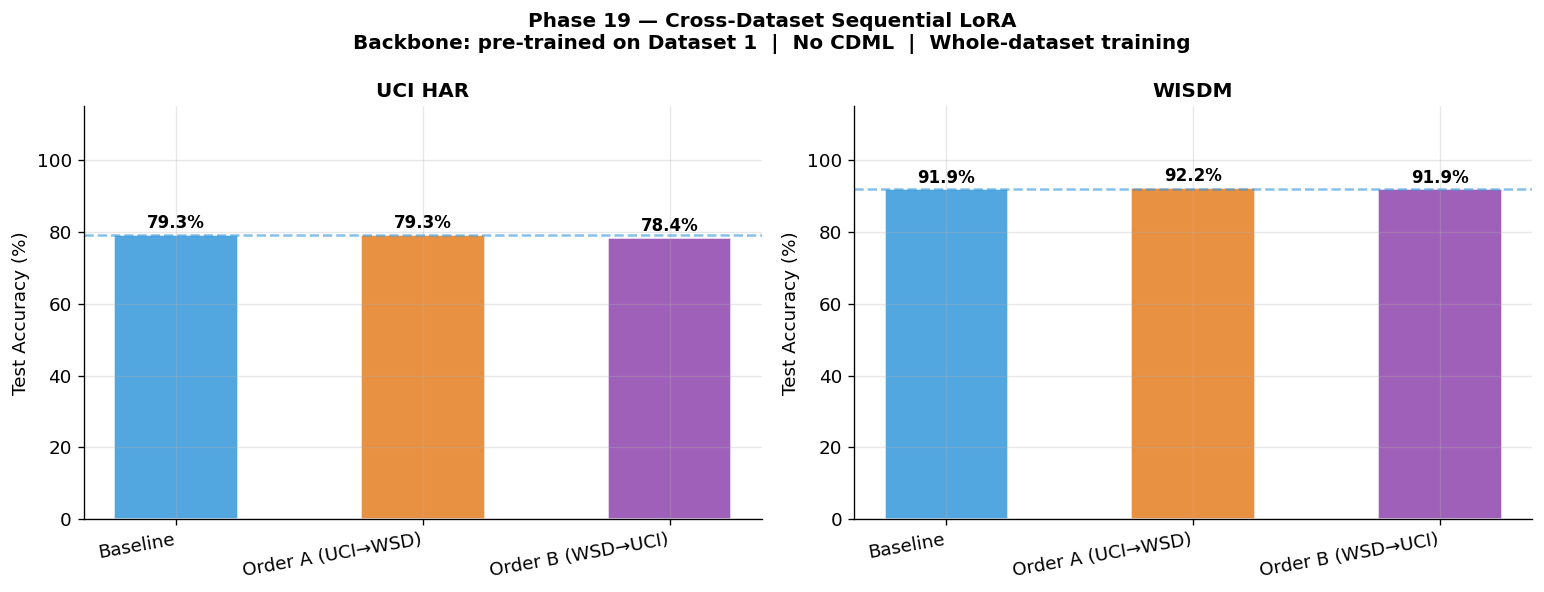

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
experiments = list(results.keys())
colors = ['#3498DB', '#E67E22', '#8E44AD']

for ax, dataset in zip(axes, ['UCI HAR', 'WISDM']):
    vals     = [results[e][dataset] * 100 for e in experiments]
    baseline = results['Baseline'][dataset] * 100

    bars = ax.bar(range(len(experiments)), vals,
                  color=colors, width=0.5, alpha=0.85, edgecolor='white')
    ax.axhline(baseline, color='#3498DB', linestyle='--', lw=1.5, alpha=0.6,
               label='Baseline')

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.set_xticks(range(len(experiments)))
    ax.set_xticklabels(experiments, rotation=10, ha='right')
    ax.set_ylim(0, 115)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(dataset, fontweight='bold', fontsize=12)

fig.suptitle(
    'Phase 19 — Cross-Dataset Sequential LoRA\n'
    'Backbone: pre-trained on Dataset 1  |  No CDML  |  Whole-dataset training',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()